# Eigenerosion

The eigenerosion algorithm is validated by comparing the numerical results
with the analytical beam-theory solution. The algorithm and the corresponding
formulas are taken from [1].

## Reference

[1] A. Pandolfi and M. Ortiz, *An eigenerosion approach to brittle fracture*, 2012.

In [5]:
import gmsh
import dolfinx.fem.petsc
import viskex
import pyvista
from mpi4py import MPI
import ufl
import numpy as np
from matplotlib import pyplot as plt

pyvista.set_jupyter_backend("static")
comm = MPI.COMM_WORLD
rank = 0

L = 6.0
b = 0.5
a = 0.1             # makes it easier to compare with the analytical solution
h = 0.1             # mesh does not corelate with the mesh size so this was adjusted

E   = 1.06
nu  = 0.27
Gc  = 0.0001
T   = 0.0035 * 10   # increased so that the correct cells will be eroded
C1  = 4.0
eta = 1e-10

eps_reg = C1 * h

LOAD_RIGHT      = 1
LOAD_LEFT       = 2
WEDGE_TOP       = 3
WEDGE_BOTTOM    = 4
BODY            = 5
POINT_BOTTOM    = 6
POINT_TOP       = 7

element = ("Lagrange", 2, (2,))

mu     = E / 2 / (1 + nu)
lmbda  = E * nu / (1 + nu) / (1 - 2 * nu)

steps = 40
u_max = 2.0

Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 20%] Meshing curve 2 (Line)
Info    : [ 30%] Meshing curve 3 (Line)
Info    : [ 40%] Meshing curve 4 (Line)
Info    : [ 50%] Meshing curve 5 (Line)
Info    : [ 60%] Meshing curve 6 (Line)
Info    : [ 70%] Meshing curve 7 (Line)
Info    : [ 80%] Meshing curve 8 (Line)
Info    : [ 90%] Meshing curve 9 (Line)
Info    : Done meshing 1D (Wall 0.000478371s, CPU 0.000683s)
Info    : Meshing 2D...
Info    : [  0%] Meshing surface 1 (Transfinite)
Info    : [ 60%] Meshing surface 2 (Transfinite)
Info    : Done meshing 2D (Wall 0.000149453s, CPU 0.000417s)
Info    : 672 nodes 1409 elements


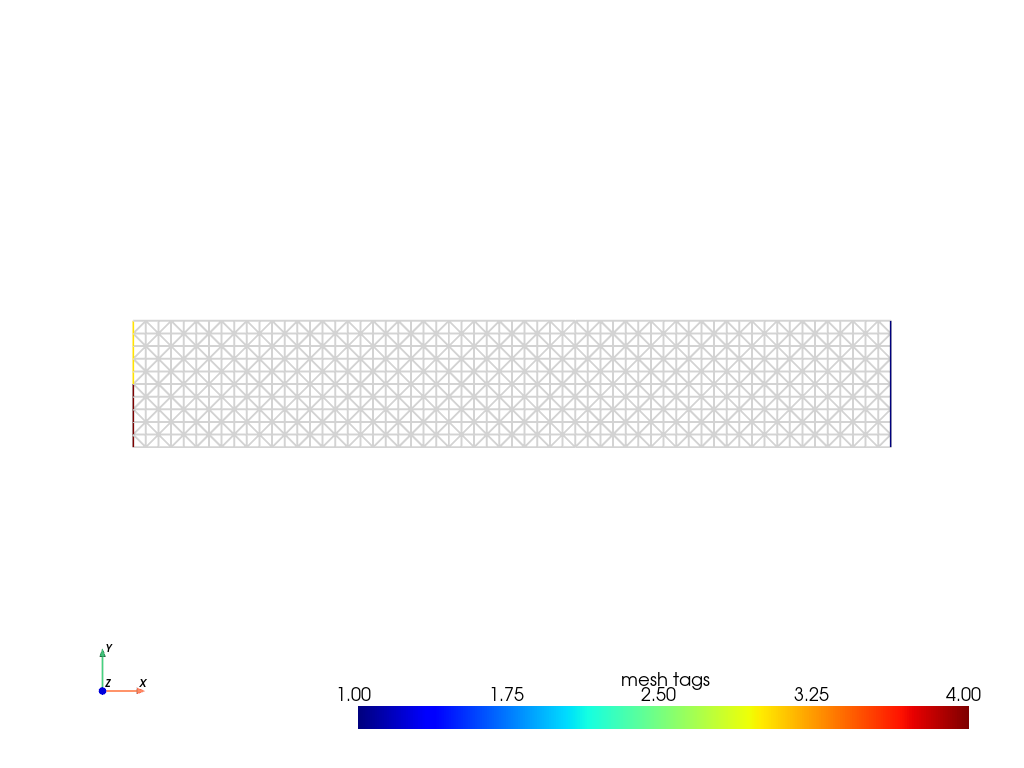

In [6]:

gdim = 2
bdim = 1
pdim = 0
gmsh.initialize()
geo = gmsh.model.geo

p1 = geo.add_point(0, 0, 0)
p2 = geo.add_point(L, 0, 0)
p3 = geo.add_point(L, b, 0)
p4 = geo.add_point(L, 2*b, 0)
p5 = geo.add_point(0, 2*b, 0)
p6 = geo.add_point(0, b, 0)
p7 = geo.add_point(a, b, 0)
p8 = geo.add_point(0, b, 0)

l1 = geo.add_line(p1, p2)
l2 = geo.add_line(p2, p3)
l3 = geo.add_line(p3, p4)
l4 = geo.add_line(p4, p5)
l5 = geo.add_line(p5, p6)
l6 = geo.add_line(p6, p7)
l7 = geo.add_line(p3, p7)
l8 = geo.add_line(p7, p8)
l9 = geo.add_line(p8, p1)

c1 = geo.add_curve_loop([l1, l2, l7, l8, l9])
c2 = geo.add_curve_loop([l3, l4, l5, l6, -l7])
s1 = geo.add_plane_surface([c1])
s2 = geo.add_plane_surface([c2])

geo.synchronize()

# Transfinite mesh
for curve_id in (l1, l4):
    gmsh.model.mesh.set_transfinite_curve(curve_id, int(L / h) + 1)

for curve_id in (l2, l3, l5, l9):
    gmsh.model.mesh.set_transfinite_curve(curve_id, int(b / h) + 1)

for curve_id in (l6, l8):
    gmsh.model.mesh.set_transfinite_curve(curve_id, int(a / h) + 1)

gmsh.model.mesh.set_transfinite_curve(l7, int((L-a) / h) + 1)

gmsh.model.mesh.set_transfinite_surface(
    s1, 
    arrangement="AlternateRight",
    cornerTags=[p1, p2, p3, p8]
)
gmsh.model.mesh.set_transfinite_surface(
    s2, 
    arrangement="AlternateLeft",
    cornerTags=[p3, p4, p5, p6]
)

gmsh.model.add_physical_group(gdim, [s1, s2], BODY)
gmsh.model.add_physical_group(bdim, [l2, l3], LOAD_RIGHT)
gmsh.model.add_physical_group(bdim, [l9], WEDGE_BOTTOM)
gmsh.model.add_physical_group(bdim, [l5], WEDGE_TOP)

gmsh.model.add_physical_group(pdim, [p1], POINT_BOTTOM)
gmsh.model.add_physical_group(pdim, [p5], POINT_TOP)

gmsh.model.mesh.generate(gdim)
mesh_data = dolfinx.io.gmsh.model_to_mesh(gmsh.model, comm, rank, gdim)

gmsh.finalize()

domain          = mesh_data.mesh
facet_tags      = mesh_data.facet_tags
cell_tags       = mesh_data.cell_tags
ridge_tags      = mesh_data.ridge_tags

tdim = domain.topology.dim
fdim = tdim - 1
rdim = fdim - 1

num_cells   = domain.topology.index_map(tdim).size_local
cells       = np.arange(num_cells, dtype=np.int32)
midpoints   = dolfinx.mesh.compute_midpoints(
    domain,
    tdim,
    cells
)

neighborhood = []

for K in range(num_cells):

    distances = np.linalg.norm(
        midpoints - midpoints[K],
        axis=1
    )

    neighborhood.append(
        np.where(distances <= eps_reg)[0]
    )

viskex.dolfinx.plot_mesh_tags(domain, facet_tags)

In [7]:
def eps(u):
    return ufl.sym(ufl.grad(u))

def sigma(u):
    return 2.0 * mu * eps(u) + lmbda * ufl.tr(eps(u)) * ufl.Identity(gdim)

dx = ufl.Measure("dx", domain=domain, subdomain_data=cell_tags)
ds = ufl.Measure("ds", domain=domain, subdomain_data=facet_tags)

V = dolfinx.fem.functionspace(domain, element)
Q = dolfinx.fem.functionspace(domain, ("DG", 0))

u_top       = dolfinx.fem.Constant(domain, 0.0)
u_bottom    = dolfinx.fem.Constant(domain, 0.0)

bc_top = dolfinx.fem.dirichletbc(
    u_top,
    dolfinx.fem.locate_dofs_topological(V.sub(1), fdim, facet_tags.find(WEDGE_TOP)),
    V.sub(1),
)

bc_bottom = dolfinx.fem.dirichletbc(
    u_bottom,
    dolfinx.fem.locate_dofs_topological(V.sub(1), fdim, facet_tags.find(WEDGE_BOTTOM)),
    V.sub(1),
)

bc_right = dolfinx.fem.dirichletbc(
    0.0,
    dolfinx.fem.locate_dofs_topological(V.sub(0), fdim, facet_tags.find(LOAD_RIGHT)),
    V.sub(0)
)

bcs = [bc_top, bc_bottom, bc_right]

u = ufl.TrialFunction(V)
v = ufl.TestFunction(V)
q = ufl.TestFunction(Q)

t_left = dolfinx.fem.Constant(
    domain, dolfinx.default_scalar_type([T, 0.0])
)

intact = dolfinx.fem.Function(Q)
intact.x.array[:] = 1.0
eroded = np.zeros(num_cells)

lhs = intact * ufl.inner(sigma(u), eps(v)) * dx
rhs = ufl.dot(t_left, v) * (
    ds(WEDGE_TOP) + ds(WEDGE_BOTTOM)
)

volume_form     = dolfinx.fem.form(q * ufl.dx)
volume_vec      = dolfinx.fem.assemble_vector(volume_form)
cell_measure    = np.zeros(num_cells)

for K in range(num_cells):
    dof = Q.dofmap.cell_dofs(K)[0]
    cell_measure[K] = volume_vec.array[dof]

problem = dolfinx.fem.petsc.LinearProblem(
    lhs,
    rhs,
    bcs=bcs,
    petsc_options_prefix="eigenerosion_",
    petsc_options={"ksp_type": "preonly", "pc_type": "lu"},
)

Step 1
Step 2
Step 3
Step 4
Step 5
Step 6
Step 7
Step 8
Step 9
Step 10
Step 11
Step 12
Step 13
Step 14
Step 15
Step 16
Step 17
Step 18
Step 19
Step 20
Step 21
Step 22
Step 23
Step 24
Step 25
Step 26
Step 27
Step 28
Step 29
Step 30
Step 31
Step 32
Step 33
Step 34
Step 35
Step 36
Step 37
Step 38
Step 39
Step 40


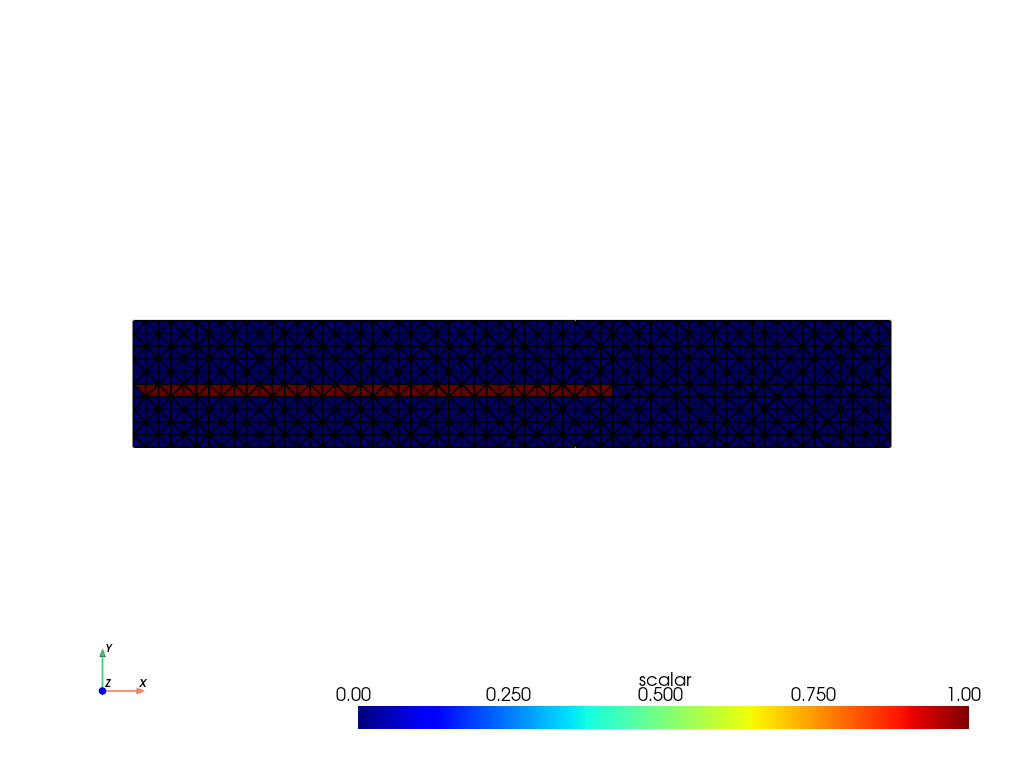

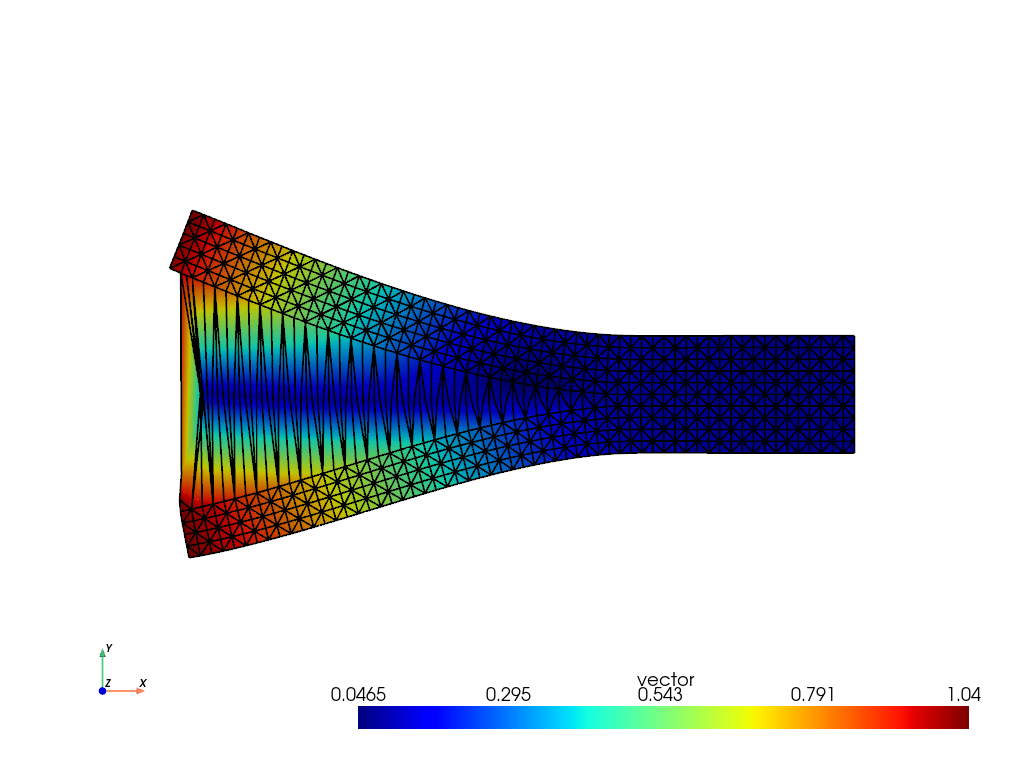

ERODED: 75.0


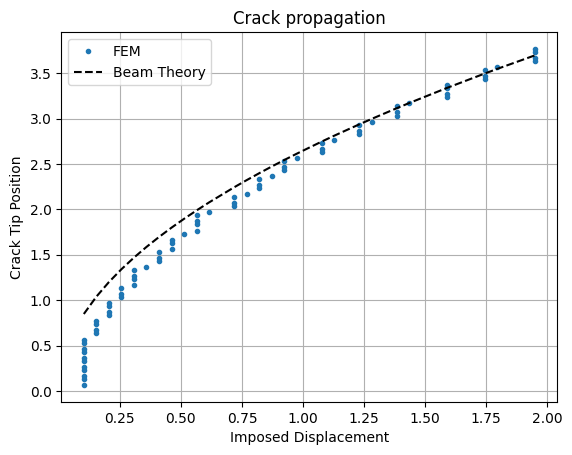

In [8]:
C_eps           = []
cracked_cell    = []

Q_vis       = dolfinx.fem.functionspace(domain, ("DG", 1))
eroded_vis  = dolfinx.fem.Function(Q_vis)
eroded_plot = dolfinx.fem.Function(Q)

u_fem = []
x_fem = []

for i in range(steps):

    print(f"Step {i+1}")

    ###### STEP N ######
    load = i / (steps - 1) * u_max
    u_top.value     = load / 2
    u_bottom.value  = -load / 2

    while True:
        uh = problem.solve()

        # Energy
        psi         = 0.5 * ufl.inner(sigma(uh), eps(uh))
        Pi_form     = intact * psi * q * dx
        Pi_vec      = dolfinx.fem.assemble_vector(dolfinx.fem.form(Pi_form))
        delta_E     = np.zeros(num_cells)
        for K in cells:
            dof = Q.dofmap.cell_dofs(K)[0]
            delta_E[K] = Pi_vec.array[dof]

        # Volume
        vol_form = ufl.div(uh) * q * dx
        vol_vec = dolfinx.fem.assemble_vector(dolfinx.fem.form(vol_form))
        vol_strain = np.zeros(num_cells)
        for K in cells:
            dof = Q.dofmap.cell_dofs(K)[0]
            vol_strain[K] = vol_vec.array[dof] / cell_measure[K]

        # Delete condition
        delta_F = np.zeros(num_cells)
        for K in cells:

            if K in cracked_cell:
                continue

            if vol_strain[K] <= 0.0:
                continue

            C_ast       = np.setdiff1d(neighborhood[K], C_eps)
            delta_AK    = (np.sum(cell_measure[C_ast]) / (2.0 * eps_reg))
            delta_F[K]  = delta_E[K] - Gc * delta_AK

        PQ = delta_F[delta_F > 0]
        if len(PQ) > 0:
            K_ast = np.argmax(delta_F)
            dof = Q.dofmap.cell_dofs(K_ast)[0]
            intact.x.array[dof] = eta
            eroded[K_ast] = 1
            C_eps.extend(neighborhood[K_ast])
            cracked_cell.append(K_ast)

            u_fem.append(load)
            x_fem.append(midpoints[K_ast][0])
        else:
            break


eroded_plot.x.array[:] = eroded
eroded_vis.interpolate(eroded_plot)
viskex.dolfinx.plot_scalar_field(eroded_vis)

viskex.dolfinx.plot_vector_field(uh, warp_factor=1.0)

print(f"ERODED: {sum(eroded)}")

d       = b
r       = 3 * E / (Gc * (1 - nu**2)) * d**3
N       = T * b
nom     = 3 * d**2 * E * np.sqrt(r) * np.array(u_fem)
den     = 3 * d**2 * E + N * np.sqrt(r) * (1 - nu**2)
a_ref   = 0.5 * np.sqrt(nom / den)


plt.plot(u_fem, x_fem, ".")
plt.plot(u_fem, a_ref, "k--")
plt.title("Crack propagation")
plt.xlabel("Imposed Displacement")
plt.ylabel("Crack Tip Position")
plt.grid(True)
plt.legend(["FEM", "Beam Theory"])
plt.show()